In [41]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc
import geocat.datafiles as gdf
import matplotlib.pyplot as plt

In [42]:
data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'

uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')

#data_path = 'hybrid_subset.nc'
#grid_path = 'grid_subset.nc'
#uxds = ux.open_dataset(grid_path, data_path)
uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_49295/4118352583.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


<xarray.UxDataset> Size: 6MB
Dimensions:  (time: 1, n_face: 48600, lev: 32, ilev: 33)
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev     (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
Dimensions without coordinates: n_face
Data variables:
    PS       (time, n_face) float32 194kB ...
    V        (time, lev, n_face) float32 6MB ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...
    hyai     (ilev) float64 264B ...
    hybi     (ilev) float64 264B ...

In [43]:
# Subsetting
uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


lon_bounds = (-110,-100)  # Full longitude
lat_bounds = (35, 45)

V_subset = uxds['V'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)
PS_subset = uxds['PS'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)

uxds = ux.UxDataset({
    'V': V_subset,
    'PS': PS_subset,
    'hyam': uxds['hyam'],
    'hybm': uxds['hybm']
}, uxgrid=V_subset.uxgrid)
uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_49295/3080202331.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


<xarray.UxDataset> Size: 13kB
Dimensions:  (lev: 32, time: 1, n_face: 89)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 11kB ...
    PS       (time, n_face) float32 356B ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...

In [44]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
ux_ipress


/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(


<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 89)> Size: 15kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 21, 89))
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [22]:
lon_bounds = (-110,-100)  # Full longitude
lat_bounds = (35, 45)

lat_array = np.arange(lat_bounds[0]+1, lat_bounds[1], 1)
lat_array


array([36, 37, 38, 39, 40, 41, 42, 43, 44])

In [23]:
# zonal mean wind
ux_v_zonal = ux_ipress.zonal_mean(lat=lat_array)
ux_v_zonal['plev'] = ux_ipress.plev
ux_v_zonal


<xarray.DataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 9)> Size: 2kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [ 1.96818606e+00,  1.66549748e+00,  1.49353417e+00,
          1.30266858e+00,  9.84371276e-01,  3.48250815e-01,
         -4.52056499e-01, -1.17046434e+00, -1.99886067e+00],
        [ 5.53867751e+00,  4.96896343e+00,  4.29294887e+00,
          3.58884207e+00,  2.81673419e+00,  1.92549283e+00,
          1.09020952e+00,  2.74910827e-01, -6.33349780e-01],
        [ 7.98080972e+00,  7.51863351e+00,  6.84731288e+00,
          6.11436117e+00,  5.22885833e+00,  4.15120302e+00,
          2.89091455e+00,  1.67225008e+00,  4.40430462e-01],
        [ 1.04505683e+01,  9.83844279e+00,  9.06780139e+00,
          8.21959690e+00,  7.34433258e+00,  6.38142823e+00,
...
         -7.24385121e+00, -7.99376126e+00, -8.77927823e+00,
         -9.60782856e+00, -1.04741278e+01, -1.13885422e+01],
        [-6.71670878e+00, -7.74041475e+00, -8.82718097e+00,
         -9.97806872e+00, -1.11874885e+01, -1.24357688e+01,
         -1.37271880e+01, -1.50498380e+01, -1.64023204e+01],
        [-6.53375579e+00, -7.76091442e+00, -9.06928122e+00,
         -1.04575278e+01, -1.19159079e+01, -1.34195791e+01,
         -1.49683811e+01, -1.65471663e+01, -1.81432392e+01],
        [-5.10821756e+00, -6.64330560e+00, -8.27944853e+00,
         -1.00065280e+01, -1.18077372e+01, -1.36543304e+01,
         -1.55405898e+01, -1.74501013e+01, -1.93547186e+01],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [24]:
ux_PS_zonal = uxds.PS.zonal_mean(lat=lat_array)
ux_PS_zonal

<xarray.DataArray 'PS_zonal_mean' (time: 1, latitudes: 9)> Size: 36B
array([[83334.195, 82125.87 , 81452.07 , 81478.664, 81912.04 , 82507.67 ,
        83321.78 , 84491.88 , 86408.78 ]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [25]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = ux_v_zonal.latitudes
da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g

In [26]:
np_dp_zonal = gc.meteorology.delta_pressure(ux_v_zonal.plev, ux_PS_zonal)

da_dp_zonal = xr.DataArray(
    np_dp_zonal,
    dims=["time", "latitudes", "plev"],
    coords={
        "plev": ux_v_zonal.plev,
        "latitudes": ux_v_zonal.latitudes
        },
    name="delta_pressure"
)
ux_dp_zonal = ux.UxDataArray(da_dp_zonal, uxgrid=uxds.uxgrid)

In [27]:
# Reverse plev, integrate, then reverse back
integrand = ux_v_zonal * ux_dp_zonal
ux_mpsi = (
    integrand.isel(plev=slice(None, None, -1))  # reverse plev: now top is first
    .cumsum(dim="plev")
)
ux_mpsi = ux_mpsi * da_scaling_factor

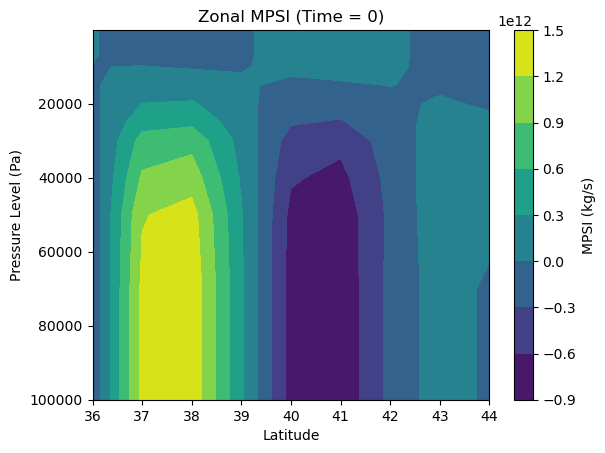

In [28]:
mpsi0 = ux_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()

In [ ]:
def zonal_mpsi(uxds, 
                lat=list(range(-90, 91, 10))):
    """
    Calculate the zonally averaged meridional mass streamfunction (mpsi) from a UXarray Dataset.

    Parameters
    ----------
    uxds : uxarray.UxDataset
        Input dataset containing the following required fields:
            - V : Meridional wind component (on pressure or hybrid sigma-pressure levels)
            - PS : Surface pressure
            - plev : Pressure levels (if V is on pressure levels)
            - hyam : Hybrid A coefficients (if V is on hybrid sigma-pressure levels)
            - hybm : Hybrid B coefficients (if V is on hybrid sigma-pressure levels)
            - uxgrid : Grid information for uxarray
    lat: list of latitudes to use for zonal mean (default: every 10 degrees from -90 to 90)

    Returns
    -------
    ux_mpsi : uxarray.UxDataArray
        Zonal mean meridional mass streamfunction, scaled by Earth's geometry and gravity.
        Dimensions: ["time", "latitudes", "plev"]

    Notes
    -----
    - Optionally converts wind data from hybrid sigma-pressure levels to pressure levels.
    - Computes zonal means and pressure integration deltas.
    - Integrates over pressure levels, handling orientation.
    - Applies scaling factor based on Earth's radius and gravity.
    - Currently only supports UXarray Datasets with specified structure.
    """

    # constants
    a = 6.371e6  # Earth radius (m)
    g = 9.80665  # gravity (m/s^2)

    # Basic input validation
    if not hasattr(uxds, "V") or not hasattr(uxds, "PS"):
        raise AttributeError(
            "zonal_mpsi: input uxds must contain 'V' and 'PS' variables"
        )

    if not hasattr(uxds, "uxgrid"):
        raise AttributeError(
            "zonal_mpsi: input uxds missing required 'uxgrid' metadata (uxarray)"
        )

    # Auto-detect whether V is already on pressure levels (prefer explicit 'plev').
    is_on_plev = False
    if "plev" in getattr(uxds.V, "coords", {}) or "plev" in getattr(uxds.V, "dims", ()):
        is_on_plev = True

    if is_on_plev:
        # accept UxDataArray or DataArray inputs
        if isinstance(uxds.V, ux.UxDataArray):
            da_ipress = uxds.V
        else:
            da = uxds.V if isinstance(uxds.V, xr.DataArray) else xr.DataArray(uxds.V)
        # Only pass a ux.Grid instance to UxDataArray; otherwise pass None
        _uxgrid = getattr(uxds, "uxgrid", None)
        grid_param = (
            _uxgrid if (hasattr(ux, "Grid") and isinstance(_uxgrid, ux.Grid)) else None
        )
        ux_ipress = ux.UxDataArray(da, uxgrid=grid_param)
    else:
        # require hybrid coefficients
        if not hasattr(uxds, "hyam") or not hasattr(uxds, "hybm"):
            raise AttributeError(
                "zonal_mpsi: input uxds must have either a 'plev' coordinate on V or hybrid coefficients 'hyam' and 'hybm'"
            )

        # determine a reasonable lev_dim to pass to the interpolator (use the last dim of V)
        lev_dim = (
            uxds.V.dims[-1]
            if hasattr(uxds.V, "dims") and len(uxds.V.dims) > 0
            else None
        )

        try:
            da_ipress = gc.interp_hybrid_to_pressure(
                uxds.V, uxds.PS, uxds.hyam, uxds.hybm, lev_dim=lev_dim
            )
        except Exception as e:
            raise RuntimeError(
                f"zonal_mpsi: failed to convert hybrid levels to pressure levels: {e}"
            )

        # Ensure we have an xarray DataArray and convert to uxarray UxDataArray
        if not isinstance(da_ipress, xr.DataArray):
            da_ipress = xr.DataArray(da_ipress)

    _uxgrid = getattr(uxds, "uxgrid", None)
    grid_param = (
        _uxgrid if (hasattr(ux, "Grid") and isinstance(_uxgrid, ux.Grid)) else None
    )
    ux_ipress = ux.UxDataArray(da_ipress, uxgrid=grid_param)

    # Require a canonical 'plev' coordinate on the pressure-level data.
    if "plev" not in ux_ipress.coords and "plev" not in ux_ipress.dims:
        raise ValueError(
            "zonal_mpsi: could not find pressure-level coordinate 'plev' in converted data; provide 'plev' or hybrid coefficients"
        )

    # Keep UX types up through the zonal_mean step, Xarray after
    da_v_zonal = ux_ipress.zonal_mean(lat=lat)

    # Zonal mean of surface pressure
    if hasattr(uxds.PS, "zonal_mean"):
        ux_PS_zonal = uxds.PS.zonal_mean(lat=lat)
    else:
        # infer a longitude dim name
        lon_dim = None
        for d in uxds.PS.dims:
            if "lon" in d or "long" in d:
                lon_dim = d
                break
        if lon_dim is None:
            raise ValueError(
                "zonal_mpsi: cannot compute zonal mean of PS; no longitude dimension found"
            )
        ux_PS_zonal = uxds.PS.mean(dim=lon_dim)
    # integration deltas
    plev_coord = da_v_zonal.coords['plev']
    dp = gc.delta_pressure(plev_coord, ux_PS_zonal)

    # Convert delta_pressure result to an xarray DataArray
    if isinstance(dp, xr.DataArray):
        da_dp_zonal = dp
    else:
        # infer dims and coords from da_v_zonal
        dims = da_v_zonal.dims
        coords = {d: da_v_zonal.coords[d] for d in dims if d in da_v_zonal.coords}
        coords['plev'] = da_v_zonal.coords['plev']
        da_dp_zonal = xr.DataArray(dp, dims=dims, coords=coords, name="delta_pressure")

    # scaling factor
    if "latitudes" not in da_v_zonal.coords:
        lat_candidates = ("lat", "latitude", "latitudes")
        lat_name = next((n for n in lat_candidates if n in da_v_zonal.coords), None)
        if lat_name is None:
            raise ValueError(
                "zonal_mpsi: could not find latitude coordinate on zonal data"
            )
    else:
        lat_name = "latitudes"

    da_scaling_factor = xr.DataArray(
        2 * np.pi * a * np.cos(da_v_zonal.coords[lat_name]) / g,
        coords={lat_name: da_v_zonal.coords[lat_name]},
        dims=(lat_name,),
    )

    # check orientation and integrate along pressure dim
    plev_values = da_v_zonal.coords["plev"].values
    increasing = plev_values[0] < plev_values[-1]

    if increasing:
        integrand = da_v_zonal * da_dp_zonal
        da_mpsi = integrand.cumsum(dim="plev")
    else:
        integrand = (da_v_zonal * da_dp_zonal).isel({"plev": slice(None, None, -1)})
        da_mpsi = integrand.cumsum(dim="plev").isel({"plev": slice(None, None, -1)})

    # apply scaling factor
    da_mpsi = da_mpsi * da_scaling_factor

    # metadata
    try:
        da_mpsi.attrs.update(
            {
                "long_name": "zonal mean meridional mass streamfunction",
                "units": "kg/s",
                "info": "zonal_mpsi: integrated meridional mass streamfunction",
            }
        )
    except Exception:
        pass

    return da_mpsi

In [31]:
z = zonal_mpsi(uxds, lats=lat_array)

/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(
/Users/jkent/miniconda3/envs/geocat_comp_build/lib/python3.13/site-packages/metpy/interpolate/one_dimension.py:160: RuntimeWarning: divide by zero encountered in divide
  var_interp = var[below] + (var[above] - var[below]) * ((x_array - xp[below])


ValueError: Zonal mean computations are currently only supported for face-centered data variables.

In [32]:
uxds

<xarray.UxDataset> Size: 13kB
Dimensions:  (lev: 32, time: 1, n_face: 89)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 11kB -5.826 -5.76 -7.465 ... 3.628 3.22
    PS       (time, n_face) float32 356B 8.085e+04 7.953e+04 ... 7.878e+04
    hyam     (lev) float64 256B 0.003643 0.007595 0.01436 ... 0.001989 0.0
    hybm     (lev) float64 256B 0.0 0.0 0.0 0.0 ... 0.9251 0.9512 0.9743 0.9926

In [33]:
data_path = 'hybrid_subset.nc'
grid_path = 'grid_subset.nc'
uxds = ux.open_dataset(grid_path, data_path)
uxds

<xarray.UxDataset> Size: 13kB
Dimensions:  (time: 1, lev: 32, n_face: 89)
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 11kB ...
    PS       (time, n_face) float32 356B ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...

In [37]:
def zonal_mpsi(uxds, 
                lat=list(range(-90, 91, 10))):
    """
    Calculate the zonally averaged meridional mass streamfunction (mpsi) from a UXarray Dataset.

    Parameters
    ----------
    uxds : uxarray.UxDataset
        Input dataset containing the following required fields:
            - V : Meridional wind component (on pressure or hybrid sigma-pressure levels)
            - PS : Surface pressure
            - plev : Pressure levels (if V is on pressure levels)
            - hyam : Hybrid A coefficients (if V is on hybrid sigma-pressure levels)
            - hybm : Hybrid B coefficients (if V is on hybrid sigma-pressure levels)
            - uxgrid : Grid information for uxarray
    lat: list of latitudes to use for zonal mean (default: every 10 degrees from -90 to 90)

    Returns
    -------
    da_mpsi : xarray.DataArray
        Zonal mean meridional mass streamfunction, scaled by Earth's geometry and gravity.
        Dimensions: ["time", "latitudes", "plev"]

    Notes
    -----
    - Optionally converts wind data from hybrid sigma-pressure levels to pressure levels.
    - Computes zonal means and pressure integration deltas.
    - Integrates over pressure levels, handling orientation.
    - Applies scaling factor based on Earth's radius and gravity.
    - Currently only supports UXarray Datasets with specified structure.
    """

    # constants
    a = 6.371e6  # Earth radius (m)
    g = 9.80665  # gravity (m/s^2)

    # Basic input validation
    if not hasattr(uxds, "V") or not hasattr(uxds, "PS"):
        raise AttributeError(
            "zonal_mpsi: input uxds must contain 'V' and 'PS' variables"
        )

    if not hasattr(uxds, "uxgrid"):
        raise AttributeError(
            "zonal_mpsi: input uxds missing required 'uxgrid' metadata (uxarray)"
        )
    
    # Check if interpolation needs to be done
    if hasattr(uxds.V, "plev") or "plev" in getattr(uxds.V, "dims", ()):
        ux_ipress = uxds
    elif hasattr(uxds, "hyam") and hasattr(uxds, "hybm"):
        da_ipress = gc.interpolation.interp_hybrid_to_pressure(
            uxds.V, 
            uxds.PS, 
            uxds.hyam, 
            uxds.hybm)
        ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
    else:
        raise AttributeError(
                "zonal_mpsi: input uxds must have either a 'plev' coordinate on V or hybrid coefficients 'hyam' and 'hybm'"
            )

    # zonal means
    da_v_zonal = ux_ipress.zonal_mean(lat=lat)
    da_v_zonal['plev'] = ux_ipress.plev
    da_PS_zonal = uxds.PS.zonal_mean(lat=lat)

    # scaling factor
    da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g

    # delta pressure for integration
    np_dp_zonal = gc.meteorology.delta_pressure(da_v_zonal.plev, da_PS_zonal)

    da_dp_zonal = xr.DataArray(
        np_dp_zonal,
        dims=["time", "latitudes", "plev"],
        coords={
            "plev": ux_v_zonal.plev,
            "latitudes": lat
            },
        name="delta_pressure"
    )

    # check orientation and integrate along pressure dim
    plev_values = da_v_zonal.coords["plev"].values
    increasing = plev_values[0] < plev_values[-1]

    if increasing:
        integrand = da_v_zonal * da_dp_zonal
        da_mpsi = integrand.cumsum(dim="plev")
    else:
        integrand = (da_v_zonal * da_dp_zonal).isel({"plev": slice(None, None, -1)})
        da_mpsi = integrand.cumsum(dim="plev").isel({"plev": slice(None, None, -1)})

    # apply scaling factor
    da_mpsi = da_mpsi * da_scaling_factor

    # metadata
    try:
        da_mpsi.attrs.update(
            {
                "long_name": "zonal mean meridional mass streamfunction",
                "units": "kg/s",
                "info": "zonal_mpsi: integrated meridional mass streamfunction",
            }
        )
    except Exception:
        pass

    return da_mpsi

/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(


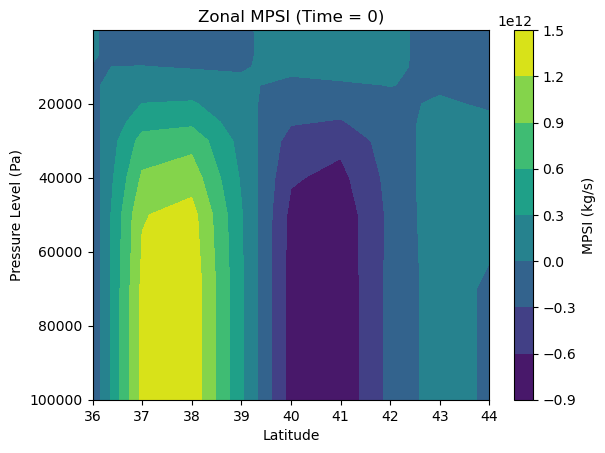

In [40]:
da_mpsi = zonal_mpsi(uxds, lat=lat_array)
mpsi0 = da_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()

In [45]:
da_mpsi

<xarray.DataArray (time: 1, plev: 21, latitudes: 9)> Size: 2kB
array([[[-2.31624810e+11,  1.27064109e+12,  1.42020577e+12,
          3.46830277e+11, -7.28333604e+11, -8.27737484e+11,
         -2.21823497e+11,  1.47328367e+11, -5.07693197e+10],
        [-2.31624810e+11,  1.27064109e+12,  1.42020577e+12,
          3.46830277e+11, -7.28333604e+11, -8.27737484e+11,
         -2.21823497e+11,  1.47328367e+11, -5.07693197e+10],
        [-2.31624810e+11,  1.27064109e+12,  1.42020577e+12,
          3.46830277e+11, -7.28333604e+11, -8.27737484e+11,
         -2.21823497e+11,  1.47328367e+11, -5.07693197e+10],
        [-2.31624810e+11,  1.27064109e+12,  1.42020577e+12,
          3.46830277e+11, -7.28333604e+11, -8.27737484e+11,
         -2.21823497e+11,  1.47328367e+11, -5.07693197e+10],
        [-2.13633709e+11,  1.17957740e+12,  1.31830984e+12,
          3.22017872e+11, -6.81436149e+11, -8.03175502e+11,
         -2.34739901e+11,  1.93741905e+11,  9.19948795e+10],
        [-1.70237590e+11,  9.46703780e+11,  1.06726538e+12,
          2.63425311e+11, -5.66411895e+11, -6.86771912e+11,
         -2.08039851e+11,  1.84397932e+11,  1.30768256e+11],
        [-1.28550603e+11,  7.11793434e+11,  8.00319128e+11,
          1.96875326e+11, -4.24061336e+11, -5.19467580e+11,
...
         -1.99673900e+10,  5.60982386e+10,  9.24876019e+10,
          4.14395166e+10, -6.31819663e+10, -1.24303418e+11],
        [ 3.66732171e+09, -2.59328147e+10, -3.76634622e+10,
         -1.20830309e+10,  3.43360046e+10,  5.71048160e+10,
          2.57526541e+10, -3.94482198e+10, -7.78233367e+10],
        [ 1.38685662e+09, -1.02132391e+10, -1.52948498e+10,
         -5.02381082e+09,  1.45390559e+10,  2.45272069e+10,
          1.11844578e+10, -1.72818990e+10, -3.43105008e+10],
        [ 5.33645600e+08, -4.15123630e+09, -6.45557699e+09,
         -2.17826286e+09,  6.42908217e+09,  1.10061041e+10,
          5.07467622e+09, -7.90817696e+09, -1.57984907e+10],
        [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False
    long name:     pressure layer thickness
    long_name:     zonal mean meridional mass streamfunction
    units:         kg/s
    info:          zonal_mpsi: integrated meridional mass streamfunction